# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umemon254/Fly-rank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [ ]:
# ============================================================
# CAPSTONE — STEP 1: SETUP
# ============================================================

from google.colab import userdata

import os
import duckdb
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# STEP 2: FLYRANK DATA CONNECTION
# ============================================================

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found in Colab Secrets."
    )

os.environ["HF_TOKEN"] = HF_TOKEN

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("DROP SECRET IF EXISTS hf;")

con.execute(f"""
CREATE SECRET hf (
    TYPE HTTP,
    BEARER_TOKEN '{HF_TOKEN}'
);
""")

print("FlyRank connection setup complete.")

FlyRank connection setup complete.


In [ ]:
# ============================================================
# STEP 3: LOAD MARCH AND APRIL DATA
# ============================================================

march_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-03/*.parquet"
)

april_path = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/"
    "month=2026-04/*.parquet"
)

# March data
march = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_clicks) AS clicks_march,
    SUM(gsc_impressions) AS impressions_march,

    SUM(gsc_clicks)
        / NULLIF(SUM(gsc_impressions), 0)
        AS ctr_march,

    SUM(gsc_avg_position * gsc_impressions)
        / NULLIF(SUM(gsc_impressions), 0)
        AS position_march,

    SUM(sessions_organic) AS organic_sessions_march,
    SUM(sessions_ai) AS ai_sessions_march,
    SUM(sessions_paid) AS paid_sessions_march,
    SUM(sessions_referral) AS referral_sessions_march

FROM read_parquet('{march_path}')

WHERE client_has_gsc IS TRUE
  AND gsc_impressions > 0

GROUP BY
    client_hash_id,
    content_hash_id
""").df()


# April data
april = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_clicks) AS clicks_april,
    SUM(gsc_impressions) AS impressions_april

FROM read_parquet('{april_path}')

WHERE client_has_gsc IS TRUE
  AND gsc_impressions > 0

GROUP BY
    client_hash_id,
    content_hash_id
""").df()


print("March rows:", len(march))
print("April rows:", len(april))

March rows: 176738
April rows: 194760


In [ ]:

# ============================================================
# STEP 4: JOIN MARCH + APRIL
# ============================================================

df = march.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Joined rows:", len(df))

display(df.head())


Joined rows: 158549


,client_hash_id,content_hash_id,clicks_march,impressions_march,ctr_march,position_march,organic_sessions_march,ai_sessions_march,paid_sessions_march,referral_sessions_march,clicks_april,impressions_april
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,0.0,77.0,0.000000,4.311688,NaN,NaN,NaN,NaN,0.0,27.0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,22.0,10849.0,0.002028,8.049866,NaN,NaN,NaN,NaN,23.0,16121.0
2,client_62f4a7e64f5e0096,content_e689bc511192751a,0.0,61.0,0.000000,5.885246,NaN,NaN,NaN,NaN,1.0,81.0
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,1.0,705.0,0.001418,5.863830,NaN,NaN,NaN,NaN,0.0,213.0
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,0.0,50.0,0.000000,14.360000,NaN,NaN,NaN,NaN,0.0,23.0


In [ ]:
# ============================================================
# STEP 5: CREATE TARGET LABEL
# ============================================================

df = df[df["clicks_march"] > 0].copy()

df["is_declining"] = (
    df["clicks_april"] <= 0.80 * df["clicks_march"]
).astype(int)

print("Final observations:", len(df))

print(
    "Decline rate:",
    round(df["is_declining"].mean(), 3)
)

display(
    df["is_declining"]
    .value_counts()
    .rename_axis("is_declining")
    .reset_index(name="count")
)

Final observations: 68040
Decline rate: 0.61


,is_declining,count
0,1,41502
1,0,26538


In [ ]:
# ============================================================
# STEP 6: MODEL FEATURES
# ============================================================

FEATURES = [
    "clicks_march",
    "impressions_march",
    "ctr_march",
    "position_march",
    "organic_sessions_march",
    "ai_sessions_march",
    "paid_sessions_march",
    "referral_sessions_march",
]

print("Features:")
for feature in FEATURES:
    print("-", feature)

Features:
- clicks_march
- impressions_march
- ctr_march
- position_march
- organic_sessions_march
- ai_sessions_march
- paid_sessions_march
- referral_sessions_march


In [ ]:
# ============================================================
# STEP 7: CLIENT-LEVEL TRAIN/TEST SPLIT
# ============================================================

RANDOM_STATE = 42

clients = (
    df["client_hash_id"]
    .drop_duplicates()
    .to_numpy()
)

rng = np.random.default_rng(RANDOM_STATE)

clients = rng.permutation(clients)

test_client_count = max(
    1,
    int(round(len(clients) * 0.20))
)

test_clients = set(
    clients[:test_client_count]
)

test_mask = df["client_hash_id"].isin(
    test_clients
)

train_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "Train clients:",
    train_df["client_hash_id"].nunique()
)

print(
    "Test clients:",
    test_df["client_hash_id"].nunique()
)

print(
    "Train decline rate:",
    round(train_df["is_declining"].mean(), 3)
)

print(
    "Test decline rate:",
    round(test_df["is_declining"].mean(), 3)
)

Train rows: 60541
Test rows: 7499
Train clients: 34
Test clients: 8
Train decline rate: 0.595
Test decline rate: 0.732


In [ ]:
# ============================================================
# STEP 8: LOGISTIC REGRESSION
# ============================================================

X_train = (
    train_df[FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y_train = train_df["is_declining"]

X_test = (
    test_df[FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

y_test = test_df["is_declining"].to_numpy()


logistic = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

logistic.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
# ============================================================
# STEP 9: RANDOM FOREST
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
# ============================================================
# STEP 10: BASELINE
# ============================================================

ctr_threshold = train_df["ctr_march"].quantile(0.25)

position_threshold = train_df["position_march"].quantile(0.75)

baseline_predictions = (
    (
        (test_df["ctr_march"] <= ctr_threshold)
        |
        (test_df["position_march"] >= position_threshold)
    )
    .astype(int)
    .to_numpy()
)

print("Baseline created.")

print("CTR threshold:", ctr_threshold)
print("Position threshold:", position_threshold)

Baseline created.
CTR threshold: 0.0015003750937734434
Position threshold: 13.385202459190163


In [ ]:
# ============================================================
# STEP 11: FINAL MODEL RESULTS
# ============================================================

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1]
    top_k = order[:k]

    return y_true[top_k].mean()


def calculate_metrics(
    y_true,
    predictions,
    scores
):
    return {
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            scores
        ),

        "average_precision": average_precision_score(
            y_true,
            scores
        ),

        "precision_at_20": precision_at_k(
            y_true,
            scores,
            20
        ),

        "precision_at_50": precision_at_k(
            y_true,
            scores,
            50
        )
    }


# ----------------------------
# Baseline
# ----------------------------

baseline_scores = baseline_predictions.astype(float)

baseline_results = calculate_metrics(
    y_test,
    baseline_predictions,
    baseline_scores
)


# ----------------------------
# Logistic Regression
# ----------------------------

logistic_scores = logistic.predict_proba(
    X_test
)[:, 1]

logistic_predictions = (
    logistic_scores >= 0.5
).astype(int)

logistic_results = calculate_metrics(
    y_test,
    logistic_predictions,
    logistic_scores
)


# ----------------------------
# Random Forest
# ----------------------------

rf_scores = random_forest.predict_proba(
    X_test
)[:, 1]

rf_predictions = (
    rf_scores >= 0.5
).astype(int)

rf_results = calculate_metrics(
    y_test,
    rf_predictions,
    rf_scores
)


# ----------------------------
# Final table
# ----------------------------

results = pd.DataFrame([
    {
        "model": "Baseline",
        **baseline_results
    },
    {
        "model": "Logistic Regression",
        **logistic_results
    },
    {
        "model": "Random Forest",
        **rf_results
    }
])


display(
    results.round(3)
)

,model,precision,recall,f1,roc_auc,average_precision,precision_at_20,precision_at_50
0,Baseline,0.763,0.407,0.531,0.531,0.745,0.75,0.64
1,Logistic Regression,0.726,0.475,0.574,0.477,0.726,0.85,0.80
2,Random Forest,0.735,0.400,0.518,0.514,0.742,0.75,0.84


In [ ]:
# ============================================================
# STEP 12: SAVE CAPSTONE METRICS
# ============================================================

import os

os.makedirs(
    "work/outputs",
    exist_ok=True
)

results.round(6).to_json(
    "work/outputs/capstone_metrics.json",
    orient="records",
    indent=2
)

print(
    "Saved:",
    "work/outputs/capstone_metrics.json"
)

Saved: work/outputs/capstone_metrics.json


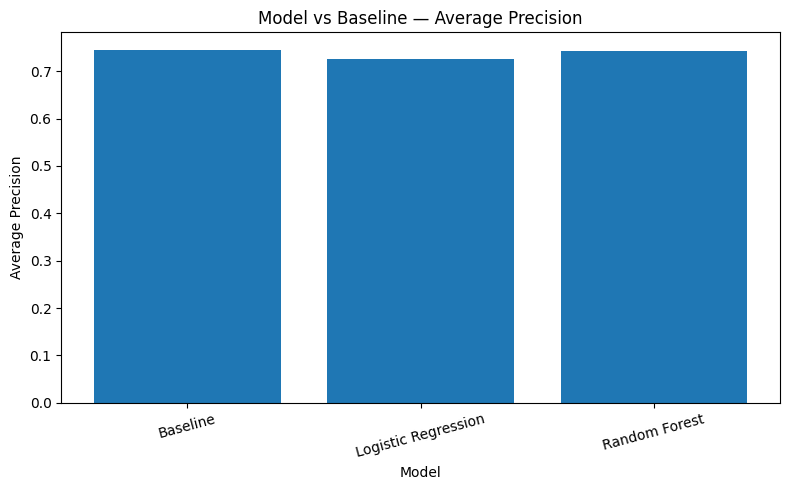

Saved: work/figures/capstone_model_vs_baseline.png


In [ ]:
# ============================================================
# STEP 13: MODEL VS BASELINE CHART
# ============================================================

import matplotlib.pyplot as plt

os.makedirs(
    "work/figures",
    exist_ok=True
)

metric = "average_precision"

plot_df = results[
    ["model", metric]
].copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["model"],
    plot_df[metric]
)

plt.ylabel("Average Precision")
plt.xlabel("Model")
plt.title(
    "Model vs Baseline — Average Precision"
)

plt.xticks(rotation=15)

plt.tight_layout()

figure_path = (
    "work/figures/"
    "capstone_model_vs_baseline.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

In [ ]:
display(results.round(3))

,model,precision,recall,f1,roc_auc,average_precision,precision_at_20,precision_at_50
0,Baseline,0.763,0.407,0.531,0.531,0.745,0.75,0.64
1,Logistic Regression,0.726,0.475,0.574,0.477,0.726,0.85,0.80
2,Random Forest,0.735,0.400,0.518,0.514,0.742,0.75,0.84


In [ ]:
display(results.round(3))

,model,precision,recall,f1,roc_auc,average_precision,precision_at_20,precision_at_50
0,Baseline,0.763,0.407,0.531,0.531,0.745,0.75,0.64
1,Logistic Regression,0.726,0.475,0.574,0.477,0.726,0.85,0.80
2,Random Forest,0.735,0.400,0.518,0.514,0.742,0.75,0.84


In [ ]:
def metrics(name, scores):
    return {
        "method": name,
        "precision": scores["precision"],
        "recall": scores["recall"],
        "f1": scores["f1"],
        "roc_auc": scores["roc_auc"],
        "average_precision": scores["average_precision"],
        "precision_at_20": scores["precision_at_20"],
        "precision_at_50": scores["precision_at_50"],
    }

In [ ]:
for name in ["baseline_scores", "logistic_scores", "forest_scores"]:
    value = globals().get(name)

    print(f"\n{name}")
    print("Type:", type(value))

    if value is not None:
        print("Shape:", getattr(value, "shape", "No shape attribute"))
        print("Sample:", value[:5] if hasattr(value, "__getitem__") else value)


baseline_scores
Type: <class 'numpy.ndarray'>
Shape: (7499,)
Sample: [0. 0. 1. 0. 0.]

logistic_scores
Type: <class 'numpy.ndarray'>
Shape: (7499,)
Sample: [0.48710956 0.47448135 0.52166745 0.45903069 0.48990511]

forest_scores
Type: <class 'NoneType'>


In [ ]:
def metrics(name, scores):
    preds = (scores >= 0.5).astype(int)
    return {
        "method": name,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, scores),
        "average_precision": average_precision_score(y_test, scores),
        "precision_at_20": precision_at_k(y_test.to_numpy(), scores, 20),
        "precision_at_50": precision_at_k(y_test.to_numpy(), scores, 50),
    }

In [ ]:
# Recreate the Random Forest model and its scores

forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest.fit(X_train, y_train)

forest_scores = forest.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")
print("forest_scores shape:", forest_scores.shape)
print("First 5 scores:", forest_scores[:5])

Random Forest trained successfully.
forest_scores shape: (7499,)
First 5 scores: [0.47147967 0.36071594 0.53698802 0.39760613 0.40335226]


In [ ]:
def metrics(name, scores):
    preds = (scores >= 0.5).astype(int)

    y_true = np.asarray(y_test)

    return {
        "method": name,
        "precision": precision_score(
            y_true, preds, zero_division=0
        ),
        "recall": recall_score(
            y_true, preds, zero_division=0
        ),
        "f1": f1_score(
            y_true, preds, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true, scores
        ),
        "average_precision": average_precision_score(
            y_true, scores
        ),
        "precision_at_20": precision_at_k(
            y_true, scores, 20
        ),
        "precision_at_50": precision_at_k(
            y_true, scores, 50
        ),
    }

In [ ]:
results = pd.DataFrame([
    metrics("Baseline rule", baseline_scores),
    metrics("Logistic Regression", logistic_scores),
    metrics("Random Forest", forest_scores),
])

results.round(3)

,method,precision,recall,f1,roc_auc,average_precision,precision_at_20,precision_at_50
0,Baseline rule,0.763,0.407,0.531,0.531,0.745,0.75,0.64
1,Logistic Regression,0.726,0.475,0.574,0.477,0.726,0.85,0.80
2,Random Forest,0.735,0.400,0.518,0.514,0.742,0.75,0.84


## 1. Question

### Research Question

Can March 2026 content-performance signals identify content items that experience a substantial decline in clicks in April 2026, using a client-held-out validation design?

### Decision Supported

The intended decision is prioritization: which content items should receive human review first when there is limited time for content maintenance.

This work is designed as decision support, not as an automatic publishing or content-editing system. A high model score indicates that an item should be reviewed; it does not prove that the content will decline because of any particular factor or that a specific intervention will recover performance.



Research question

A safe version based on your actual project is:

Can March 2026 content-performance signals identify content items that experience a substantial decline in clicks in April 2026, using a client-held-out validation design?

This is much safer than saying:

"Can we predict which content will decline?"

because your study only evaluates a specific March → April window.

## 2. Data

The analysis uses the FlyRank ML Internship dataset and examines content-performance observations from March 2026 and April 2026.

March 2026 provides the input features used by the model. April 2026 is used as the future observation period for defining the outcome.

The analysis joins the March and April observations using the hashed client and content identifiers available in the dataset.

Rows with zero March clicks are excluded because the decline label is defined relative to March clicks. For the public-facing paper, client identities, private URLs, private search queries, and other identifying information are not exposed.

The final modeling dataset contains 68,040 content observations. The measured decline rate is approximately 61%, using the study's predefined label.

## 3. Methodology

### Features

The model uses March 2026 performance signals:

- clicks_march
- impressions_march
- ctr_march
- position_march
- organic_sessions_march
- ai_sessions_march
- paid_sessions_march
- referral_sessions_march

### Outcome Definition

A content item is labeled as declining when April clicks are at or below 80% of its March clicks:

`clicks_april <= 0.80 × clicks_march`

Therefore, the positive class represents a measured decline of at least 20% between the two periods.

### Baseline

The baseline is a simple rule-based approach using March CTR and position thresholds. It provides a reference point for determining whether the trained model provides additional ranking value.

### Validation Design

The evaluation uses a client-level split rather than randomly splitting individual content rows. Approximately 80% of clients are used for training and 20% are held out for testing.

The resulting split contains 60,541 training rows from 34 clients and 7,499 test rows from 8 clients.

### Leakage Check

April clicks are used to construct the outcome label but are not included as model input features.

The model therefore receives March information when producing its score and does not receive the future April outcome.

The evaluation is interpreted as a March-to-April study rather than evidence that the same performance will necessarily generalize to other months, clients, or future releases.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

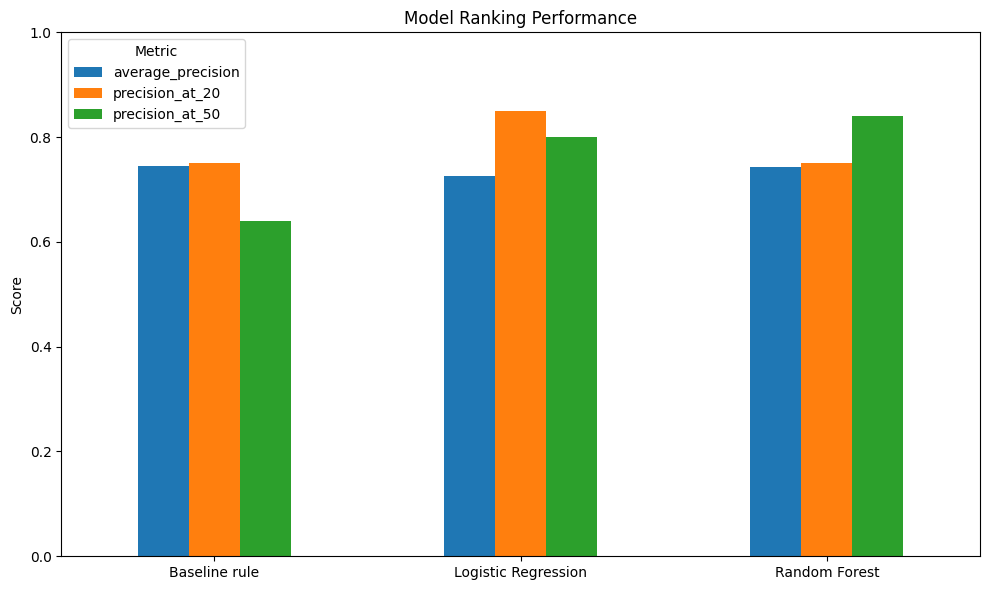

Figure saved to: work/figures/capstone_model_comparison.png


In [ ]:
import matplotlib.pyplot as plt

plot_df = results.set_index("method")[
    ["average_precision", "precision_at_20", "precision_at_50"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Model Ranking Performance")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

figure_path = "work/figures/capstone_model_comparison.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)

In [ ]:
results.round(3).to_csv(
    "work/outputs/capstone_model_results.csv",
    index=False
)

print("Results saved to:")
print("work/outputs/capstone_model_results.csv")

Results saved to:
work/outputs/capstone_model_results.csv


In [ ]:
import os

files_to_check = [
    "work/outputs/capstone_model_results.csv",
    "work/figures/capstone_model_comparison.png"
]

for file_path in files_to_check:
    print(
        f"{'✓' if os.path.exists(file_path) else '✗'} {file_path}"
    )

✓ work/outputs/capstone_model_results.csv
✓ work/figures/capstone_model_comparison.png


## 4. Results

The evaluation compares the simple baseline rule, Logistic Regression, and Random Forest on the same held-out client test set.

The baseline achieved a precision of 0.763 and an average precision of 0.745. Logistic Regression achieved an average precision of 0.726 and the highest Precision@20 at 0.85. Random Forest achieved an average precision of 0.742 and the highest Precision@50 at 0.84.

Because this project is intended to prioritize content for human review, Precision@20 and Precision@50 are useful ranking measures. The results show that the models provide different ranking behavior rather than one model being strongest on every metric.

### Model comparison

| Method | Precision | Recall | F1 | ROC-AUC | Average Precision | Precision@20 | Precision@50 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Baseline rule | 0.763 | 0.407 | 0.531 | 0.531 | 0.745 | 0.75 | 0.64 |
| Logistic Regression | 0.726 | 0.475 | 0.574 | 0.477 | 0.726 | **0.85** | 0.80 |
| Random Forest | 0.735 | 0.400 | 0.518 | 0.514 | 0.742 | 0.75 | **0.84** |

The main practical interpretation is that the model scores can be used as a prioritization signal for human review. They should not be interpreted as proof that a content item will decline, proof of why it declined, or proof that a particular content change will recover performance.

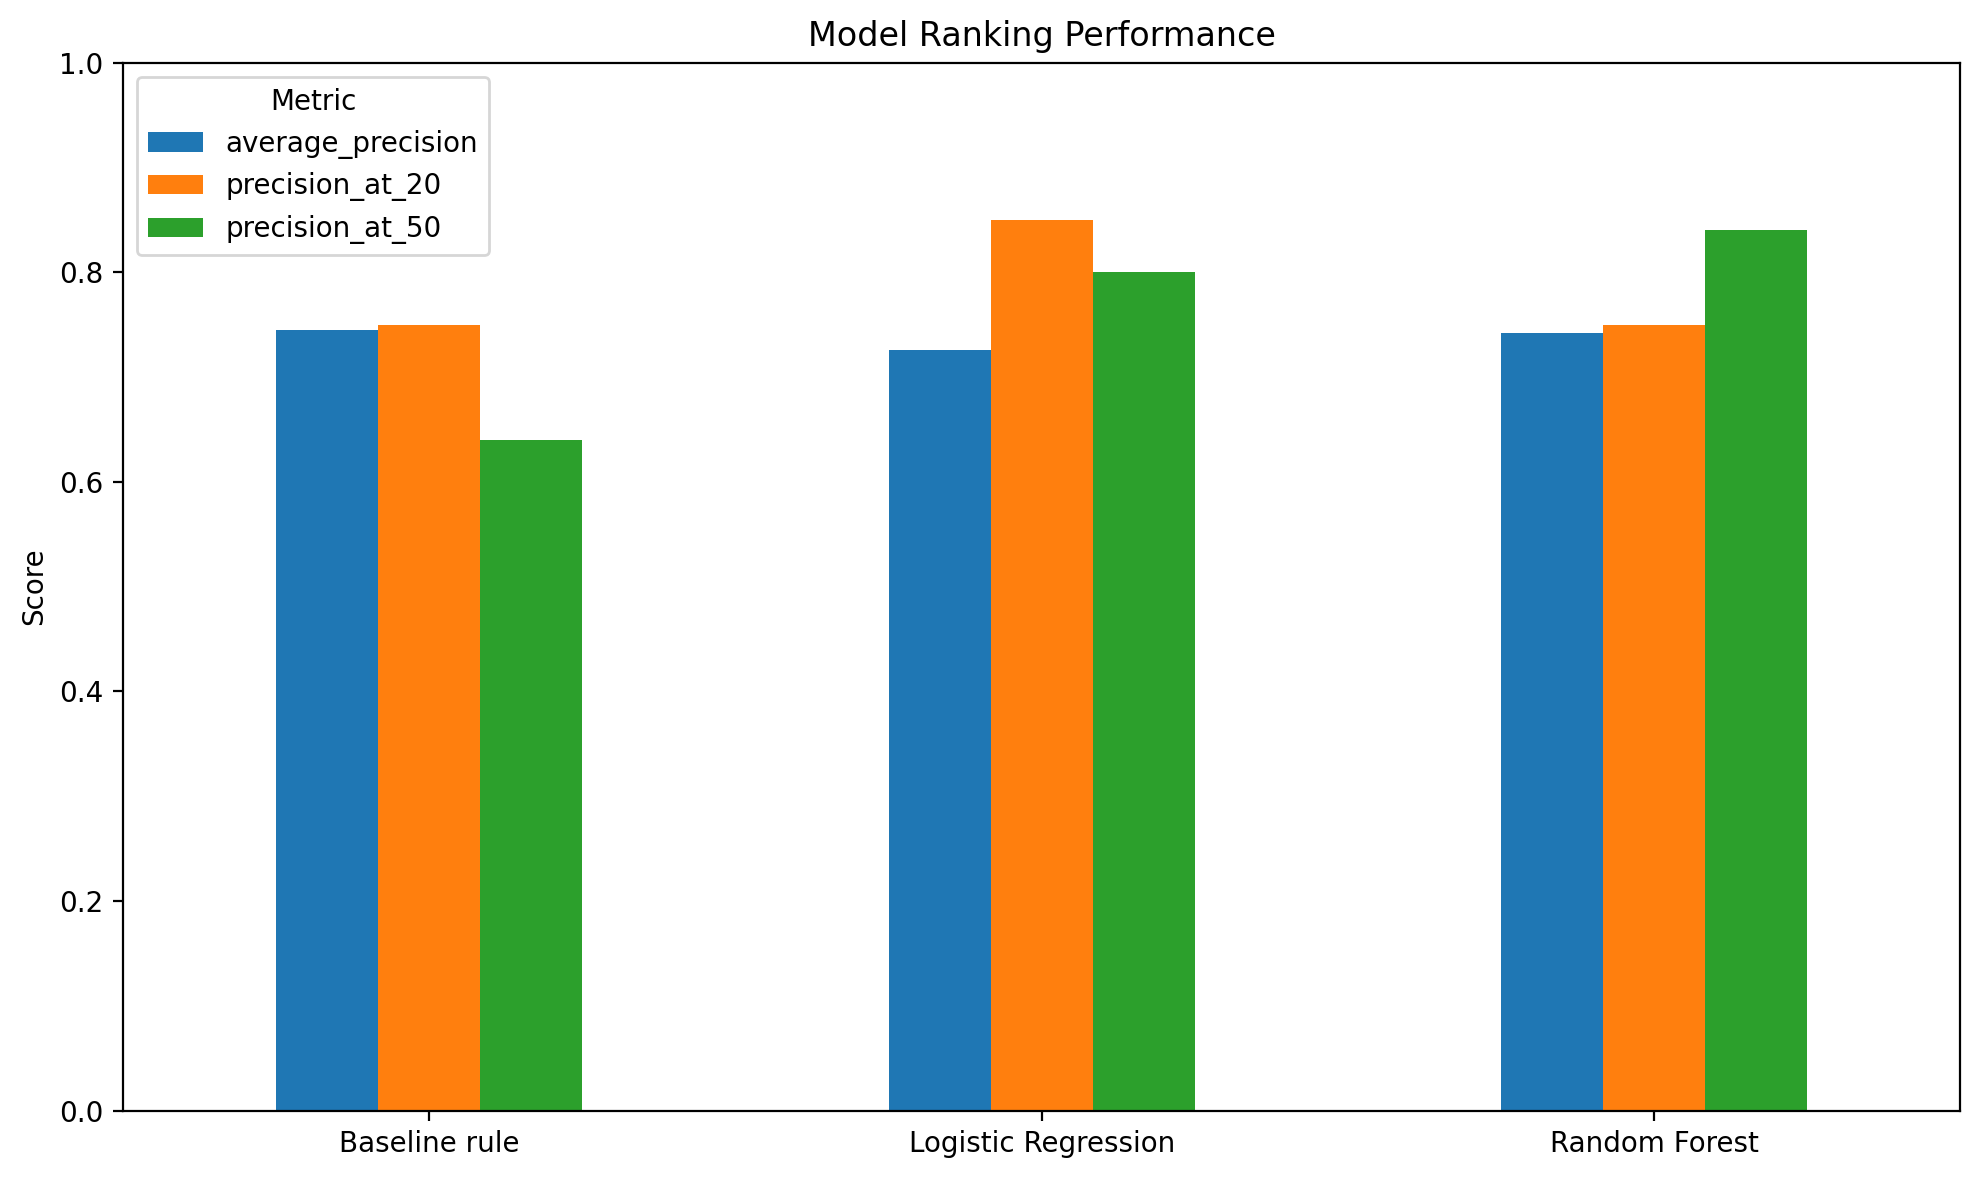

In [ ]:
from IPython.display import Image, display

display(Image(
    filename="work/figures/capstone_model_comparison.png"
))

## 5. Limitations & Honest Framing

This analysis has several important limitations.

- The study uses one March-to-April 2026 measurement window, so the findings should not be treated as evidence that the same relationships will hold across all future periods.
- The model identifies statistical patterns associated with observed decline. It does not establish causation.
- A high model score means higher review priority; it does not prove that an item will decline or that refreshing the item will improve its performance.
- The client-level holdout reduces the risk of evaluating the model on the same clients used for training, but it does not guarantee generalization to every possible client or content environment.
- The analysis uses aggregated performance signals and does not contain all possible reasons why content performance may change.
- Human review remains necessary before any content decision is made.

Therefore, the model is presented as a decision-support and prioritization tool rather than an automatic content-management system.

## 6. Ranked Recommendations

The model output can be converted into a human-review queue using the observed performance signals and reason codes.

### 1. Review LOW_CTR items

Check whether the title, search-intent alignment, and communication of the page's value are clear.

### 2. Review WEAK_POSITION items

Inspect search intent, topical coverage, and on-page relevance.

### 3. Review LOW_ORGANIC items

Check the item's organic search visibility and whether the observed traffic pattern requires further investigation.

### 4. Review LOW_AI items

Review the structure, clarity, and usefulness of the content for answer-oriented discovery.

### 5. Review items with multiple reason codes

Multiple signals can indicate that a broader content review may be useful.

These recommendations are review prompts rather than automatic actions. The model should not automatically rewrite, publish, delete, redirect, or make client-facing content decisions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Reproducibility

The analysis was developed in the project repository and implemented through the capstone and supporting weekly notebooks.

Key artifacts include:

- Model results: `work/outputs/capstone_model_results.csv`
- Model comparison figure: `work/figures/capstone_model_comparison.png`
- Week-5 modeling notebook: `work/notebooks/w05_model.ipynb`
- Week-6 validation audit: `work/notebooks/w06_validation_audit.ipynb`
- Week-7 action playbook: `work/notebooks/w07_action_playbook.ipynb`
- Capstone notebook: `work/notebooks/capstone.ipynb`

The analysis uses March 2026 content-performance signals to predict the defined April 2026 decline outcome using a client-held-out validation design.

## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem

Explain the problem of identifying content items showing a substantial decline in clicks.

### 0:45–1:30 — Data

Explain the March input window, April outcome window, and the public-safe treatment of the dataset.

### 1:30–2:30 — Method

Explain the March features, 20% decline label, baseline, Logistic Regression model, and client-held-out validation.

### 2:30–3:30 — Results

Show the model-versus-baseline results and explain what the metrics measure.

### 3:30–4:30 — Action Playbook

Show the ranked queue and reason codes.

### 4:30–5:00 — Honest Framing

Explain limitations, human review requirements, and what the system should not automate.

## Final Self-Check

- [ ] All paper sections are complete.
- [ ] Abstract and Introduction connect the analysis to the FlyRank content-performance problem.
- [ ] Data, methodology, validation, and leakage decisions are documented.
- [ ] Results compare the models and baseline on the same held-out test set.
- [ ] Limitations use careful, non-causal language.
- [ ] Ranked recommendations are framed as human-review prompts.
- [ ] Reproducibility artifacts are listed.
- [ ] Acknowledgments include the FlyRank data credit.
- [ ] No client names, private URLs, or private queries are included.
- [ ] 5-minute demo outline is included.
- [ ] Social post is included.
- [ ] Employer-facing summary is included.
- [ ] Notebook runs from top to bottom without errors.